In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set style for visualizations
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# 1. Load the dataset
df = pd.read_csv("RTA Dataset.csv")

# 2. Standardize missing values (replace 'na' strings with actual NaN)
df.replace("na", np.nan, inplace=True)

# 3. Convert 'Time' to datetime and extract the hour
df["Time"] = pd.to_datetime(df["Time"], format="%H:%M:%S", errors="coerce")
df["Hour_of_day"] = df["Time"].dt.hour

# Drop the original Time column as we now have 'Hour_of_day'
df.drop(columns=["Time"], inplace=True)

# 4. Handle Missing Values
# For categorical columns, we'll fill missing values with 'Unknown'
categorical_cols = df.select_dtypes(include=["object"]).columns
df[categorical_cols] = df[categorical_cols].fillna("Unknown")

# For numerical columns (like Hour_of_day if any dropped), we use the median
df["Hour_of_day"] = df["Hour_of_day"].fillna(df["Hour_of_day"].median())

print("--- Dataset Info Post-Preprocessing ---")
print(df.info())

--- Dataset Info Post-Preprocessing ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Day_of_week                  12316 non-null  object
 1   Age_band_of_driver           12316 non-null  object
 2   Sex_of_driver                12316 non-null  object
 3   Educational_level            12316 non-null  object
 4   Vehicle_driver_relation      12316 non-null  object
 5   Driving_experience           12316 non-null  object
 6   Type_of_vehicle              12316 non-null  object
 7   Owner_of_vehicle             12316 non-null  object
 8   Service_year_of_vehicle      12316 non-null  object
 9   Defect_of_vehicle            12316 non-null  object
 10  Area_accident_occured        12316 non-null  object
 11  Lanes_or_Medians             12316 non-null  object
 12  Road_allignment              12316 non-null  obj

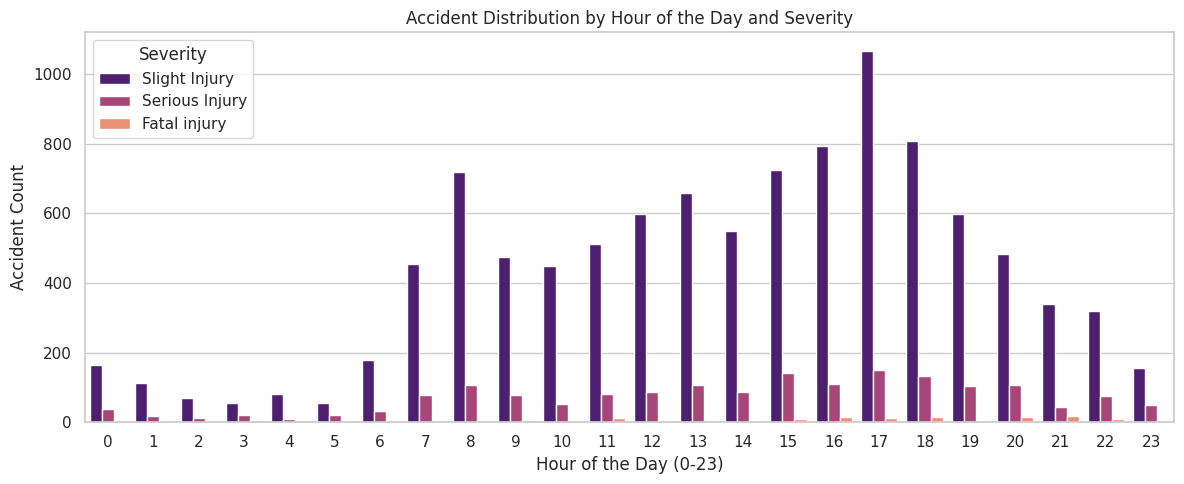

In [ ]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x="Hour_of_day", hue="Accident_severity", palette="magma")
plt.title("Accident Distribution by Hour of the Day and Severity")
plt.xlabel("Hour of the Day (0-23)")
plt.ylabel("Accident Count")
plt.legend(title="Severity", loc="upper left")
plt.tight_layout()
plt.show()

/tmp/ipykernel_29642/776087254.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cause_counts.values, y=cause_counts.index, palette="viridis")


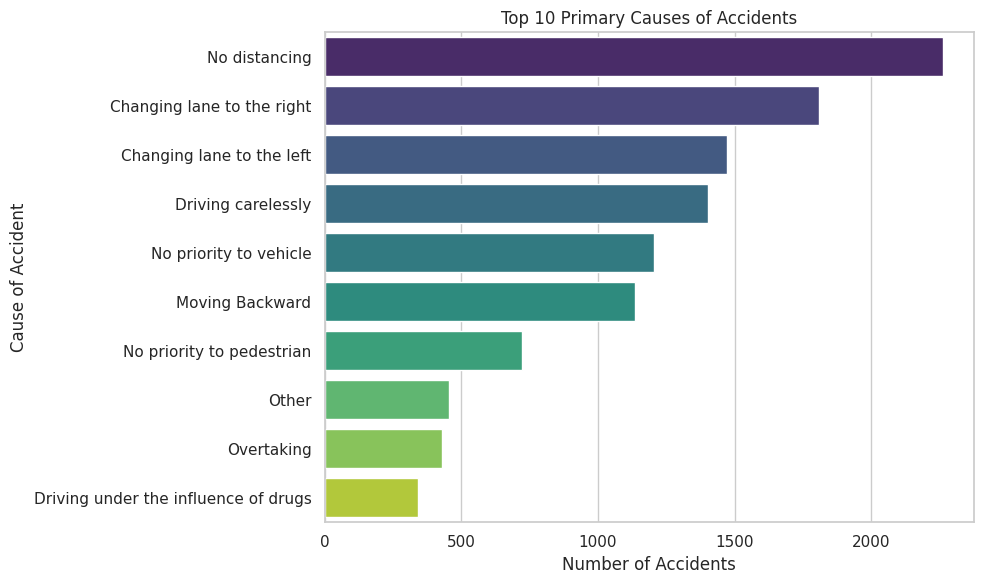

In [ ]:
plt.figure(figsize=(10, 6))
cause_counts = df["Cause_of_accident"].value_counts().head(10)
sns.barplot(x=cause_counts.values, y=cause_counts.index, palette="viridis")
plt.title("Top 10 Primary Causes of Accidents")
plt.xlabel("Number of Accidents")
plt.ylabel("Cause of Accident")
plt.tight_layout()
plt.show()

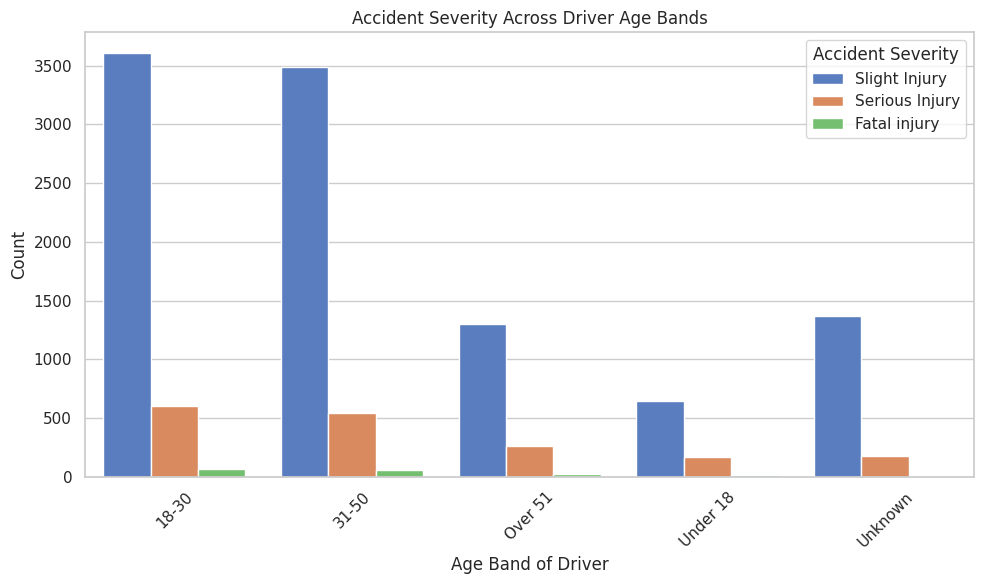

In [ ]:
plt.figure(figsize=(10, 6))
# Ordering the age bands logically for better presentation
age_order = sorted(df["Age_band_of_driver"].unique())
if "Unknown" in age_order:
    age_order.remove("Unknown")
    age_order.append("Unknown")

sns.countplot(
    data=df,
    x="Age_band_of_driver",
    hue="Accident_severity",
    order=age_order,
    palette="muted",
)
plt.title("Accident Severity Across Driver Age Bands")
plt.xlabel("Age Band of Driver")
plt.ylabel("Count")
plt.legend(title="Accident Severity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
print("--- CRITICAL INSIGHTS ANALYSIS ---\n")

# 1. Severity Breakdown
print("1. Accident Severity Distribution:")
severity_percentage = df["Accident_severity"].value_counts(normalize=True) * 100
print(severity_percentage.map("{:.2f}%".format).to_string())
print("\n" + "-" * 40 + "\n")

# 2. High-Risk Driving Experience
print("2. Accident Counts by Driver Experience:")
exp_counts = df["Driving_experience"].value_counts()
print(exp_counts)
print("\n" + "-" * 40 + "\n")

# 3. Contingency Table: Weather Conditions vs Accident Severity
print("3. Weather Conditions vs Accident Severity (Cross-tabulation):")
weather_severity_cross = pd.crosstab(
    df["Weather_conditions"], df["Accident_severity"]
)
print(weather_severity_cross)

--- CRITICAL INSIGHTS ANALYSIS ---

1. Accident Severity Distribution:
Accident_severity
Slight Injury     84.56%
Serious Injury    14.15%
Fatal injury       1.28%

----------------------------------------

2. Accident Counts by Driver Experience:
Driving_experience
5-10yr        3363
2-5yr         2613
Above 10yr    2262
1-2yr         1756
Below 1yr     1342
Unknown        829
No Licence     118
unknown         33
Name: count, dtype: int64

----------------------------------------

3. Weather Conditions vs Accident Severity (Cross-tabulation):
Accident_severity   Fatal injury  Serious Injury  Slight Injury
Weather_conditions                                             
Cloudy                         0               8            117
Fog or mist                    0               1              9
Normal                       135            1474           8454
Other                          0              28            268
Raining                       23             158           1150
R

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder

# 1. Load and Quick Preprocess
df = pd.read_csv("RTA Dataset.csv")
df.replace("na", np.nan, inplace=True)

# Parse Time feature
df["Time"] = pd.to_datetime(df["Time"], format="%H:%M:%S", errors="coerce")
df["Hour_of_day"] = df["Time"].dt.hour.fillna(df["Time"].dt.hour.median())
df.drop(columns=["Time"], inplace=True)

# 2. Select Features & Handle Missing Values
# Dropping columns with massive missing data or text leakages if any
features = [
    "Day_of_week",
    "Age_band_of_driver",
    "Sex_of_driver",
    "Driving_experience",
    "Type_of_vehicle",
    "Area_accident_occured",
    "Light_conditions",
    "Weather_conditions",
    "Type_of_collision",
    "Number_of_vehicles_involved",
    "Number_of_casualties",
    "Hour_of_day",
    "Cause_of_accident",
]
target = "Accident_severity"

X = df[features].copy()
y = df[target].copy()

# Fill categorical NaNs with a placeholder string
categorical_cols = X.select_dtypes(include=["object"]).columns
X[categorical_cols] = X[categorical_cols].fillna("Unknown")

# 3. Encode Categorical Features
encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value", unknown_value=-1
)
X[categorical_cols] = encoder.fit_transform(X[categorical_cols])

# 4. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Initialize and Train Random Forest
# 'class_weight="balanced"' handles the heavy class imbalance inherent in accident data
rf_model = RandomForestClassifier(
    n_estimators=100, max_depth=12, class_weight="balanced", random_state=42
)
rf_model.fit(X_train, y_train)

# 6. Predictions & Evaluation
y_pred = rf_model.predict(X_test)

print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))

print("\n=== CONFUSION MATRIX ===")
cm = confusion_matrix(y_test, y_pred, labels=rf_model.classes_)
cm_df = pd.DataFrame(cm, index=rf_model.classes_, columns=rf_model.classes_)
print(cm_df)

# 7. Feature Importance
importances = rf_model.feature_importances_
feat_importances = pd.Series(importances, index=X.columns).sort_values(
    ascending=False
)
print("\n=== TOP 5 FEATURE IMPORTANCES ===")
print(feat_importances.head(5))

=== CLASSIFICATION REPORT ===
                precision    recall  f1-score   support

  Fatal injury       0.50      0.10      0.16        31
Serious Injury       0.36      0.13      0.20       349
 Slight Injury       0.86      0.96      0.91      2084

      accuracy                           0.83      2464
     macro avg       0.57      0.40      0.42      2464
  weighted avg       0.78      0.83      0.80      2464


=== CONFUSION MATRIX ===
                Fatal injury  Serious Injury  Slight Injury
Fatal injury               3               0             28
Serious Injury             0              47            302
Slight Injury              3              84           1997

=== TOP 5 FEATURE IMPORTANCES ===
Number_of_casualties    0.147669
Hour_of_day             0.143139
Cause_of_accident       0.097195
Day_of_week             0.095523
Type_of_vehicle         0.087351
dtype: float64
